In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akash2907/bird-species-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bird-species-classification' dataset.
Path to dataset files: /kaggle/input/bird-species-classification


In [17]:
! cp -r /kaggle/input/bird-species-classification /content/dataset

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np

In [19]:
train_path = "/content/dataset/train_data/train_data"
test_path = "/content/dataset/test_data/test_data"

In [23]:
imgage_size = (224 , 224)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

Found 150 files belonging to 16 classes.
Using 120 files for training.


Found 150 files belonging to 16 classes.
Using 30 files for validation.
Found 157 files belonging to 16 classes.


In [24]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 16
['blasti', 'bonegl', 'brhkyt', 'cbrtsh', 'cmnmyn', 'gretit', 'hilpig', 'himbul', 'himgri', 'hsparo', 'indvul', 'jglowl', 'lbicrw', 'mgprob', 'rebimg', 'wcrsrt']


In [25]:
AutoTune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AutoTune)
validation_ds = validation_ds.cache().prefetch(buffer_size=AutoTune)
test_ds = test_ds.cache().prefetch(buffer_size=AutoTune)

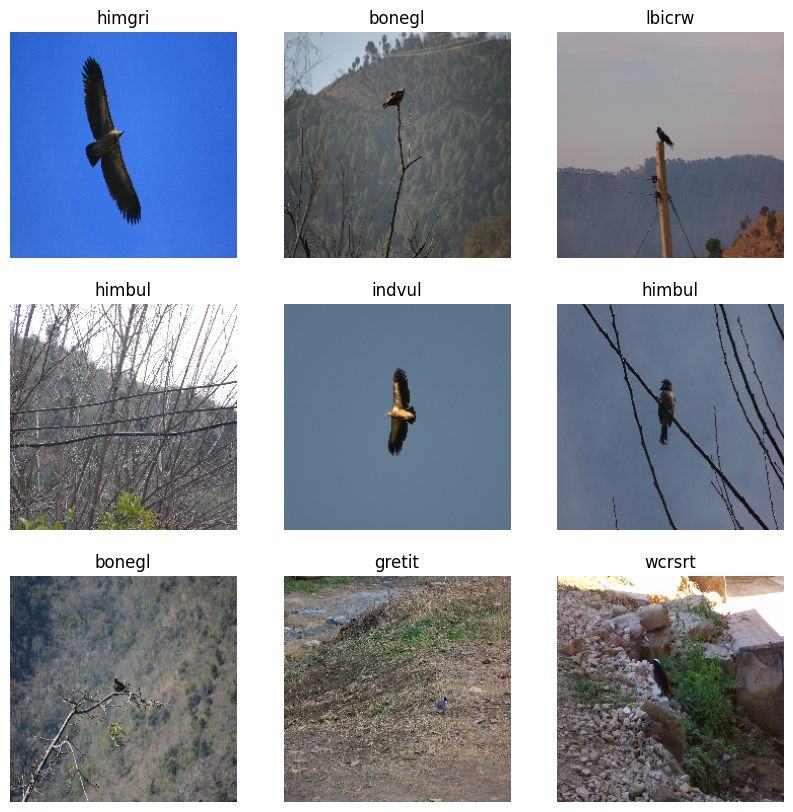

In [28]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()